In [14]:
import gc
gc.collect()

import os
import re
import glob

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt

import awkward as ak

In [2]:
# Base path that contains MuonBucketDump_<sample>/outputs/MuonBucketDump*.root
BASE_DIR = "/media/hdd/ddicroce/data/"

# Match all current and future samples automatically
SAMPLE_GLOB = os.path.join(BASE_DIR, "MuonBucketDump_*", "outputs", "MuonBucketDump*.root")


In [17]:
# ----------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------
def flatten_common_event_hash(evh_arr):
    if isinstance(evh_arr, np.ndarray):
        if evh_arr.ndim == 2:
            if evh_arr.shape[1] == 1:
                return evh_arr[:, 0].astype(np.int64)
            if evh_arr.shape[1] == 2:
                return np.array([f"{int(a)}_{int(b)}" for a, b in evh_arr], dtype=object)

    out = []
    for x in evh_arr:
        flat = np.ravel(x)
        if len(flat) == 1:
            out.append(np.int64(flat[0]))
        else:
            out.append(f"{int(flat[0])}_{int(flat[1])}")
    return np.asarray(out, dtype=object)


def find_common_event_hash_key(branches):
    for b in branches:
        if b == "CommonEventHash" or b.startswith("CommonEventHash"):
            return b
    raise KeyError("Could not find CommonEventHash branch")


def discover_samples(sample_glob):
    """
    Returns:
        dict[sample_name] = sorted list of ROOT files
    where sample_name is the part after 'MuonBucketDump_' in the folder name.
    """
    files = sorted(glob.glob(sample_glob))
    samples = {}

    for fpath in files:
        sample_dir = os.path.basename(os.path.dirname(os.path.dirname(fpath)))
        m = re.match(r"MuonBucketDump_(.+)", sample_dir)
        sample_name = m.group(1) if m else sample_dir
        samples.setdefault(sample_name, []).append(fpath)

    return samples


# ----------------------------------------------------------------------
# Vertex selection from MuonVertexDump
# ----------------------------------------------------------------------
def load_vertex_hashes_passing_calo_requirement(
    file_list,
    tree_name="MuonVertexDump",
    r_max=8000.0,
    z_max=12000.0,
):
    """
    Return a set of event hashes for events where ALL truth vertices satisfy:
        sqrt(x^2 + y^2) <= r_max
        abs(z) <= z_max
    """
    if not file_list:
        raise ValueError("file_list is empty")

    with uproot.open(file_list[0]) as f:
        all_branches = list(f[tree_name].keys())

    evh_key = find_common_event_hash_key(all_branches)

    needed = [
        evh_key,
        "truthMuonVertexPositionX",
        "truthMuonVertexPositionY",
        "truthMuonVertexPositionZ",
    ]

    arrays_per_file = []
    for fname in file_list:
        with uproot.open(fname) as f:
            arrs = f[tree_name].arrays(expressions=needed, library="ak")
            arrays_per_file.append(arrs)

    vertex_hashes = ak.concatenate([arrs[evh_key] for arrs in arrays_per_file], axis=0)
    vertex_x = ak.concatenate([arrs["truthMuonVertexPositionX"] for arrs in arrays_per_file], axis=0)
    vertex_y = ak.concatenate([arrs["truthMuonVertexPositionY"] for arrs in arrays_per_file], axis=0)
    vertex_z = ak.concatenate([arrs["truthMuonVertexPositionZ"] for arrs in arrays_per_file], axis=0)

    vertex_r = np.sqrt(vertex_x**2 + vertex_y**2)
    vertex_inside = (vertex_r <= r_max) & (np.abs(vertex_z) <= z_max)

    # Keep event only if ALL its vertices are inside
    event_mask = ak.all(vertex_inside, axis=1)

    kept_hashes = {
        h for h in flatten_common_event_hash(ak.to_numpy(vertex_hashes[event_mask]))
    }

    return kept_hashes


# ----------------------------------------------------------------------
# Load ML score bias at bucket level
# ----------------------------------------------------------------------
def load_bucket_truth_scores(file_list, tree_name="MuonBucketDump"):
    """
    Load only the branches needed for the plot, deduplicate by event_hash,
    then explode to bucket level.
    """
    if not file_list:
        raise ValueError("file_list is empty")

    with uproot.open(file_list[0]) as f:
        all_branches = list(f[tree_name].keys())

    evh_key = find_common_event_hash_key(all_branches)

    needed = [
        evh_key,
        "mb_bucket_hasTruth" if "mb_bucket_hasTruth" in all_branches else "bucket_hasTruth",
        "mb_bucket_ml_score_class0" if "mb_bucket_ml_score_class0" in all_branches else "bucket_ml_score_class0",
        "mb_bucket_ml_score_class1" if "mb_bucket_ml_score_class1" in all_branches else "bucket_ml_score_class1",
        "mb_bucket_ml_score_class2" if "mb_bucket_ml_score_class2" in all_branches else "bucket_ml_score_class2",
    ]

    arrays_per_file = []
    for fname in file_list:
        with uproot.open(fname) as f:
            arrs = f[tree_name].arrays(expressions=needed, library="np")
            arrays_per_file.append(arrs)

    merged = {}
    for b in needed:
        merged[b] = np.concatenate([arrs[b] for arrs in arrays_per_file], axis=0)

    event_hash = flatten_common_event_hash(merged[evh_key])

    hasTruth_key = needed[1]
    c0_key = needed[2]
    c1_key = needed[3]
    c2_key = needed[4]

    df = pd.DataFrame({
        "event_hash": event_hash,
        "mb_bucket_hasTruth": list(merged[hasTruth_key]),
        "mb_bucket_ml_score_class0": list(merged[c0_key]),
        "mb_bucket_ml_score_class1": list(merged[c1_key]),
        "mb_bucket_ml_score_class2": list(merged[c2_key]),
    })

    # Keep one row per event
    df = df.groupby("event_hash", as_index=False, sort=False).first()

    # Go to bucket level
    bucket_df = df.explode(
        [
            "mb_bucket_hasTruth",
            "mb_bucket_ml_score_class0",
            "mb_bucket_ml_score_class1",
            "mb_bucket_ml_score_class2",
        ],
        ignore_index=True
    )

    bucket_df["mb_bucket_hasTruth_num"] = pd.to_numeric(
        bucket_df["mb_bucket_hasTruth"],
        errors="coerce"
    )

    c0 = pd.to_numeric(bucket_df["mb_bucket_ml_score_class0"], errors="coerce")
    c1 = pd.to_numeric(bucket_df["mb_bucket_ml_score_class1"], errors="coerce")
    c2 = pd.to_numeric(bucket_df["mb_bucket_ml_score_class2"], errors="coerce")

    bucket_df["mb_bucket_ml_score_signal_margin"] = c0 - pd.concat([c1, c2], axis=1).max(axis=1)

    return bucket_df


# ----------------------------------------------------------------------
# Plot comparison: without and with vertex requirement
# ----------------------------------------------------------------------
def plot_truth_histograms_by_sample_with_vertex_comparison(
    samples_dict,
    bins=100,
    hist_range=(-5, 5),
    density=False,
    r_max=8000.0,
    z_max=12000.0,
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_all = axes[0]
    ax_sel = axes[1]

    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            bucket_df = load_bucket_truth_scores(file_list)

            vals_all = pd.to_numeric(
                bucket_df.loc[
                    bucket_df["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            kept_hashes = load_vertex_hashes_passing_calo_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_max=r_max,
                z_max=z_max,
            )

            bucket_df_sel = bucket_df[bucket_df["event_hash"].isin(kept_hashes)]

            vals_sel = pd.to_numeric(
                bucket_df_sel.loc[
                    bucket_df_sel["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            if len(vals_all) == 0:
                print(f"[WARNING] No hasTruth==1 entries for sample {sample_name} (all events)")
            else:
                ax_all.hist(
                    vals_all,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_all)})"
                )

            if len(vals_sel) == 0:
                print(f"[WARNING] No hasTruth==1 entries for sample {sample_name} (vertex-selected)")
            else:
                ax_sel.hist(
                    vals_sel,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_sel)})"
                )

            mean_all = vals_all.mean() if len(vals_all) else float("nan")
            mean_sel = vals_sel.mean() if len(vals_sel) else float("nan")

            print(
                f"[OK] {sample_name}: "
                f"all truth buckets={len(vals_all)}, mean_all={mean_all:.3f}; "
                f"inside-calo truth buckets={len(vals_sel)}, mean_sel={mean_sel:.3f}"
            )

        except Exception as e:
            print(f"[ERROR] Failed for sample {sample_name}: {e}")

    ax_all.set_xlabel("ML bucket filter: Bias value")
    ax_all.set_ylabel("Normalized buckets" if density else "Buckets")
    ax_all.set_title("Signal margin for truth buckets\n(all events)")
    ax_all.grid(True)

    ax_sel.set_xlabel("ML bucket filter: Bias value")
    ax_sel.set_title(
        f"Signal margin for truth buckets\nALL vertices inside: R <= {r_max:.0f} mm, |Z| <= {z_max:.0f} mm"
    )
    ax_sel.grid(True)

    ymax0 = ax_all.get_ylim()[1]
    ymax1 = ax_sel.get_ylim()[1]
    ymax = max(ymax0, ymax1)
    ax_all.set_ylim(0, ymax * 1.25)
    ax_sel.set_ylim(0, ymax * 1.25)

    ax_all.legend(loc="upper right", framealpha=0.9)
    ax_sel.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    plt.show()


def print_percentage_above_threshold_with_vertex_comparison(
    samples_dict,
    threshold=1,
    r_max=8000.0,
    z_max=12000.0,
):
    print(f"\nPercentage of truth buckets with bias > {threshold}")
    print(f"Vertex-selected means: keep events where ALL vertices satisfy R <= {r_max} mm and |Z| <= {z_max} mm")

    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            bucket_df = load_bucket_truth_scores(file_list)

            vals_all = pd.to_numeric(
                bucket_df.loc[
                    bucket_df["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            kept_hashes = load_vertex_hashes_passing_calo_requirement(
                file_list=file_list,
                tree_name="MuonVertexDump",
                r_max=r_max,
                z_max=z_max,
            )

            bucket_df_sel = bucket_df[bucket_df["event_hash"].isin(kept_hashes)]

            vals_sel = pd.to_numeric(
                bucket_df_sel.loc[
                    bucket_df_sel["mb_bucket_hasTruth_num"] == 1,
                    "mb_bucket_ml_score_signal_margin"
                ],
                errors="coerce"
            ).dropna()

            if len(vals_all) == 0:
                msg_all = "all: no truth buckets"
            else:
                n_above_all = (vals_all > threshold).sum()
                pct_all = (vals_all > threshold).mean() * 100
                msg_all = f"all: {pct_all:.2f}% ({n_above_all}/{len(vals_all)})"

            if len(vals_sel) == 0:
                msg_sel = "inside-calo: no truth buckets"
            else:
                n_above_sel = (vals_sel > threshold).sum()
                pct_sel = (vals_sel > threshold).mean() * 100
                msg_sel = f"inside-calo: {pct_sel:.2f}% ({n_above_sel}/{len(vals_sel)})"

            print(f"  {sample_name}: {msg_all} | {msg_sel}")

        except Exception as e:
            print(f"  {sample_name}: ERROR - {e}")

# ML Bucket Filter cut

Discovered samples:
  HAHM_ggFHZdZd_mumu_3000_0p005: 7 files
  HAHM_ggFHZdZd_mumu_400_0p0001: 9 files
  HNL2_ctau1000: 7 files
  HNL3_ctau1000: 8 files
[OK] HAHM_ggFHZdZd_mumu_3000_0p005: all truth buckets=15620, mean_all=-1.351; inside-calo truth buckets=15616, mean_sel=-1.351
[OK] HAHM_ggFHZdZd_mumu_400_0p0001: all truth buckets=15454, mean_all=-1.160; inside-calo truth buckets=15454, mean_sel=-1.160
[OK] HNL2_ctau1000: all truth buckets=13505, mean_all=-1.798; inside-calo truth buckets=3840, mean_sel=-1.462
[OK] HNL3_ctau1000: all truth buckets=13763, mean_all=-1.752; inside-calo truth buckets=5090, mean_sel=-1.466


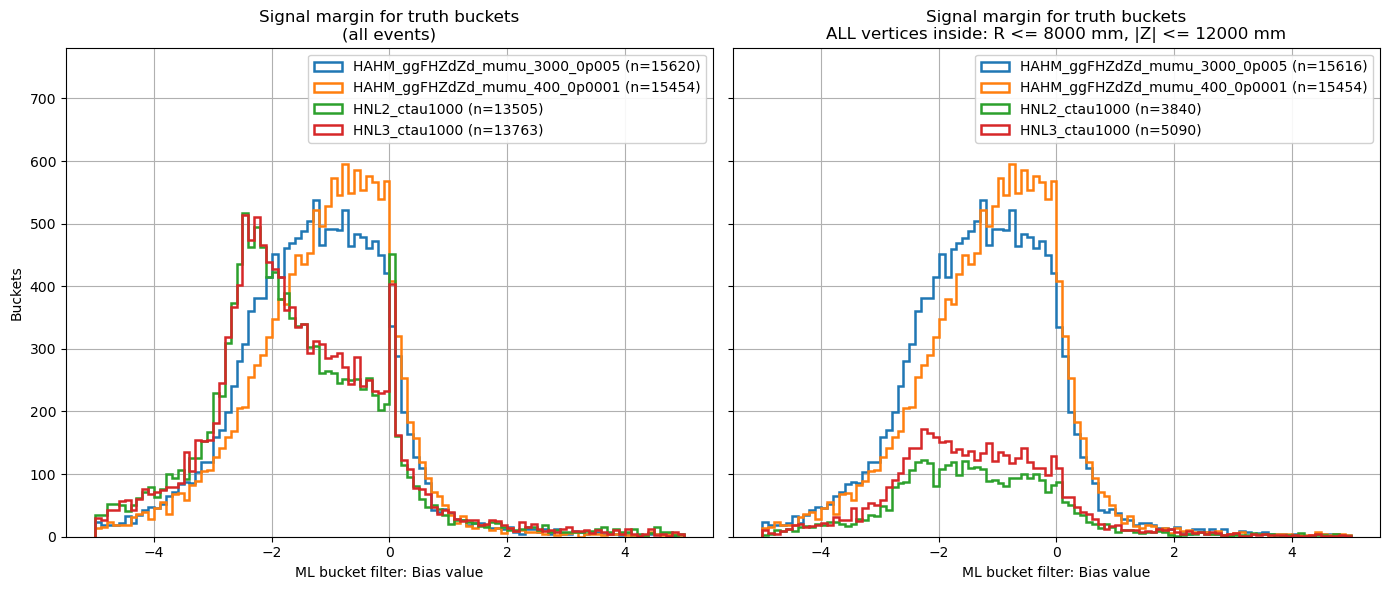


Percentage of truth buckets with bias > 1
Vertex-selected means: keep events where ALL vertices satisfy R <= 8000.0 mm and |Z| <= 12000.0 mm
  HAHM_ggFHZdZd_mumu_3000_0p005: all: 2.79% (436/15620) | inside-calo: 2.79% (436/15616)
  HAHM_ggFHZdZd_mumu_400_0p0001: all: 2.56% (396/15454) | inside-calo: 2.56% (396/15454)
  HNL2_ctau1000: all: 4.41% (596/13505) | inside-calo: 4.84% (186/3840)
  HNL3_ctau1000: all: 4.64% (639/13763) | inside-calo: 4.77% (243/5090)


In [18]:
# -------------------------------------------------------------------
# Main
# -------------------------------------------------------------------
R_MAX = 8000.0   # mm
Z_MAX = 12000.0  # mm

samples = discover_samples(SAMPLE_GLOB)

print("Discovered samples:")
for s, flist in sorted(samples.items()):
    print(f"  {s}: {len(flist)} files")

plot_truth_histograms_by_sample_with_vertex_comparison(
    samples_dict=samples,
    bins=100,
    hist_range=(-5, 5),
    density=False,
    r_max=R_MAX,
    z_max=Z_MAX,
)

print_percentage_above_threshold_with_vertex_comparison(
    samples_dict=samples,
    threshold=1,
    r_max=R_MAX,
    z_max=Z_MAX,
)

# Segments

In [15]:
# ----------------------------------------------------------------------
# Segments/event, with and without vertex calo-envelope requirement
# ----------------------------------------------------------------------
def load_segments_per_event(file_list, bucket_tree_name="MuonBucketDump"):
    """
    Return a pandas Series:
        index   = event_hash
        values  = total number of segments in that event
    computed from MuonBucketDump.
    """
    if not file_list:
        raise ValueError("file_list is empty")

    with uproot.open(file_list[0]) as f:
        all_branches = list(f[bucket_tree_name].keys())

    evh_key = find_common_event_hash_key(all_branches)

    if "segmentPositionX" in all_branches:
        seg_key = "segmentPositionX"
    elif "mb_segmentPositionX" in all_branches:
        seg_key = "mb_segmentPositionX"
    else:
        raise KeyError("Could not find segmentPositionX branch")

    arrays_per_file = []
    for fname in file_list:
        with uproot.open(fname) as f:
            arrs = f[bucket_tree_name].arrays([evh_key, seg_key], library="ak")
            arrays_per_file.append(arrs)

    event_hash = flatten_common_event_hash(
        ak.to_numpy(ak.concatenate([arrs[evh_key] for arrs in arrays_per_file], axis=0))
    )
    segment_x = ak.concatenate([arrs[seg_key] for arrs in arrays_per_file], axis=0)

    nseg_per_entry = ak.to_numpy(ak.num(segment_x, axis=1))

    df = pd.DataFrame({
        "event_hash": event_hash,
        "nseg_entry": nseg_per_entry,
    })

    # Sum segments over all bucket entries with same event hash
    return df.groupby("event_hash", sort=False)["nseg_entry"].sum()


def load_vertex_hashes_passing_calo_requirement(
    file_list,
    vertex_tree_name="MuonVertexDump",
    r_max=8000.0,
    z_max=12000.0,
):
    """
    Return the set of event hashes for events where ALL vertices satisfy:
        sqrt(x^2 + y^2) <= r_max
        abs(z) <= z_max
    """
    if not file_list:
        raise ValueError("file_list is empty")

    with uproot.open(file_list[0]) as f:
        all_branches = list(f[vertex_tree_name].keys())

    evh_key = find_common_event_hash_key(all_branches)

    needed = [
        evh_key,
        "truthMuonVertexPositionX",
        "truthMuonVertexPositionY",
        "truthMuonVertexPositionZ",
    ]

    for b in needed[1:]:
        if b not in all_branches:
            raise KeyError(f"Could not find branch {b} in {vertex_tree_name}")

    arrays_per_file = []
    for fname in file_list:
        with uproot.open(fname) as f:
            arrs = f[vertex_tree_name].arrays(needed, library="ak")
            arrays_per_file.append(arrs)

    vertex_hashes = ak.concatenate([arrs[evh_key] for arrs in arrays_per_file], axis=0)
    vertex_x = ak.concatenate([arrs["truthMuonVertexPositionX"] for arrs in arrays_per_file], axis=0)
    vertex_y = ak.concatenate([arrs["truthMuonVertexPositionY"] for arrs in arrays_per_file], axis=0)
    vertex_z = ak.concatenate([arrs["truthMuonVertexPositionZ"] for arrs in arrays_per_file], axis=0)

    vertex_r = np.sqrt(vertex_x**2 + vertex_y**2)
    vertex_inside = (vertex_r <= r_max) & (np.abs(vertex_z) <= z_max)

    # Keep event only if ALL its vertices are inside
    event_mask = ak.all(vertex_inside, axis=1)

    kept_hashes = {
        h for h in flatten_common_event_hash(ak.to_numpy(vertex_hashes[event_mask]))
    }

    return kept_hashes


def plot_segments_two_panel_comparison(
    samples_dict,
    bins=100,
    hist_range=None,
    density=False,
    r_max=8000.0,
    z_max=12000.0,
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_all = axes[0]
    ax_sel = axes[1]

    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            segments_per_event = load_segments_per_event(file_list)
            vals_all = segments_per_event.to_numpy()

            kept_hashes = load_vertex_hashes_passing_calo_requirement(
                file_list,
                r_max=r_max,
                z_max=z_max,
            )

            vals_sel = segments_per_event[segments_per_event.index.isin(kept_hashes)].to_numpy()

            if len(vals_all) > 0:
                ax_all.hist(
                    vals_all,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_all)})",
                )

            if len(vals_sel) > 0:
                ax_sel.hist(
                    vals_sel,
                    bins=bins,
                    range=hist_range,
                    histtype="step",
                    linewidth=1.8,
                    density=density,
                    label=f"{sample_name} (n={len(vals_sel)})",
                )

            print(
                f"[OK] {sample_name}: "
                f"all={len(vals_all)}, mean_all={vals_all.mean():.2f if len(vals_all) else float('nan')}, "
                f"inside_calo={len(vals_sel)}, mean_sel={vals_sel.mean():.2f if len(vals_sel) else float('nan')}"
            )

        except Exception as e:
            print(f"[ERROR] Failed for sample {sample_name}: {e}")

    ax_all.set_xlabel("Number of segments per event")
    ax_all.set_ylabel("Normalized events" if density else "Events")
    ax_all.set_title("Segments per event\n(all events)")
    ax_all.grid(True)
    ax_all.legend(loc="upper right", framealpha=0.9)

    ax_sel.set_xlabel("Number of segments per event")
    ax_sel.set_title(
        f"Segments per event\nALL vertices inside: R <= {r_max:.0f} mm, |Z| <= {z_max:.0f} mm"
    )
    ax_sel.grid(True)
    ax_sel.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    plt.show()


def print_segments_comparison_stats(samples_dict, r_max=8000.0, z_max=12000.0):
    print(f"\nSegments/event comparison")
    print(f"Vertex selection: keep events where ALL vertices satisfy R <= {r_max} mm and |Z| <= {z_max} mm")

    for sample_name, file_list in sorted(samples_dict.items()):
        try:
            segments_per_event = load_segments_per_event(file_list)
            vals_all = segments_per_event.to_numpy()

            kept_hashes = load_vertex_hashes_passing_calo_requirement(
                file_list,
                r_max=r_max,
                z_max=z_max,
            )

            vals_sel = segments_per_event[segments_per_event.index.isin(kept_hashes)].to_numpy()

            if len(vals_all) == 0:
                print(f"  {sample_name}: no events")
                continue

            msg = (
                f"  {sample_name}: "
                f"all n={len(vals_all)}, mean={vals_all.mean():.2f}, max={vals_all.max()}"
            )

            if len(vals_sel) > 0:
                msg += f" | inside-calo n={len(vals_sel)}, mean={vals_sel.mean():.2f}, max={vals_sel.max()}"
            else:
                msg += " | inside-calo n=0"

            print(msg)

        except Exception as e:
            print(f"  {sample_name}: ERROR - {e}")

[ERROR] Failed for sample HAHM_ggFHZdZd_mumu_3000_0p005: Invalid format specifier
[ERROR] Failed for sample HAHM_ggFHZdZd_mumu_400_0p0001: Invalid format specifier
[ERROR] Failed for sample HNL2_ctau1000: Invalid format specifier
[ERROR] Failed for sample HNL3_ctau1000: Invalid format specifier


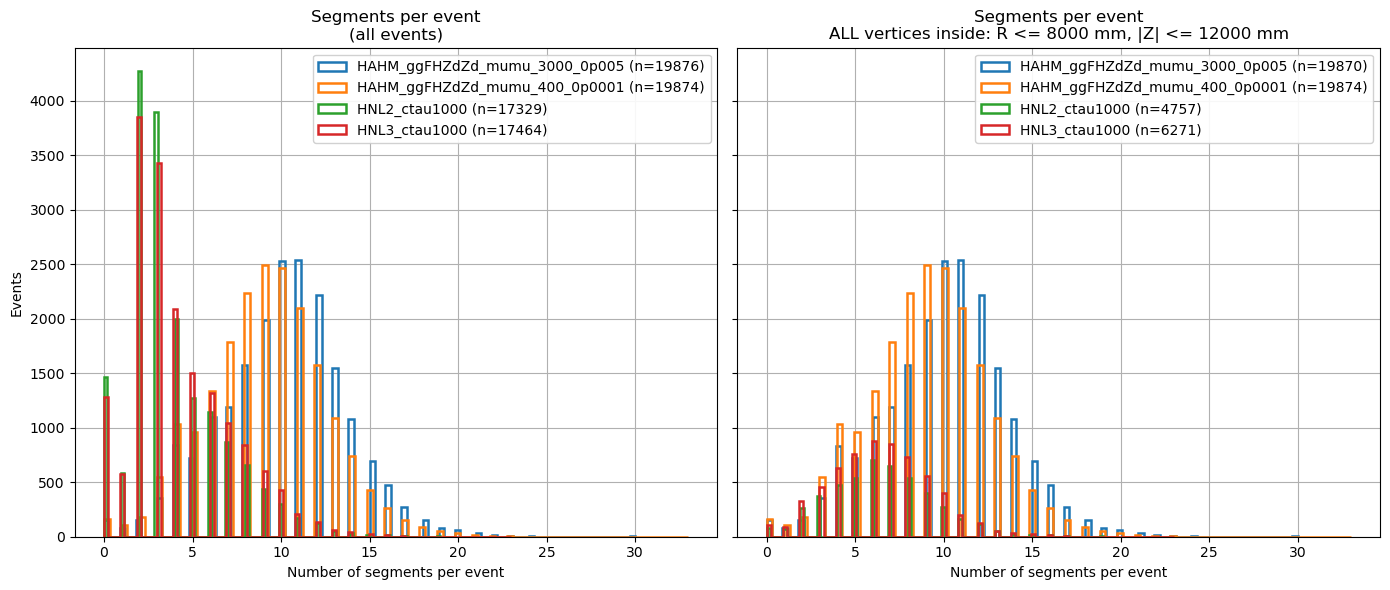


Segments/event comparison
Vertex selection: keep events where ALL vertices satisfy R <= 8000.0 mm and |Z| <= 12000.0 mm
  HAHM_ggFHZdZd_mumu_3000_0p005: all n=19876, mean=10.00, max=30 | inside-calo n=19870, mean=10.00, max=30
  HAHM_ggFHZdZd_mumu_400_0p0001: all n=19874, mean=9.08, max=33 | inside-calo n=19874, mean=9.08, max=33
  HNL2_ctau1000: all n=17329, mean=3.78, max=19 | inside-calo n=4757, mean=6.40, max=19
  HNL3_ctau1000: all n=17464, mean=4.14, max=23 | inside-calo n=6271, mean=6.43, max=23


In [16]:
plot_segments_two_panel_comparison(
    samples_dict=samples,
    bins=100,
    hist_range=None,   # or e.g. (0, 500)
    density=False,
    r_max=8000.0,
    z_max=12000.0,
)

print_segments_comparison_stats(
    samples_dict=samples,
    r_max=8000.0,
    z_max=12000.0,
)